In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("voltage_analysis.csv")
df_old = pd.read_csv("../../guide4_Li02_Na2/generated_crystals_cifs/voltage_analysis.csv")
df_train = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20/train.csv")
df_train_diff = pd.read_csv("/home/ilgar/MatterGen_extractLi/datasets/li_data_20_diff/train.csv")

In [3]:
df

,pretty_formula,filename,num_atoms,host_energy,Li_energy,Na_energy,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,host_structure,Li_structure,Na_structure
0,CrNiO2,gen_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LiVCr2O6,gen_1,10.0,-66.836499,-72.997096,-71.653185,-7.426278,-7.299710,-7.165319,1.217397,0.797386,# generated using pymatgen\ndata_VCr2O6\n_symm...,# generated using pymatgen\ndata_LiVCr2O6\n_sy...,# generated using pymatgen\ndata_NaVCr2O6\n_sy...
2,Co3CuO4,gen_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LiEuCrFeO6,gen_100,10.0,-66.515138,-72.545608,-71.566838,-7.390571,-7.254561,-7.156684,1.087270,1.032400,# generated using pymatgen\ndata_EuCrFeO6\n_sy...,# generated using pymatgen\ndata_LiEuCrFeO6\n_...,# generated using pymatgen\ndata_NaEuCrFeO6\n_...
4,Cr2NiO4,gen_1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,AlCr2O4,gen_995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2044,LiCr3NiO4,gen_996,9.0,-53.535520,-56.812406,-55.323539,-6.691940,-6.312490,-6.147060,-1.666314,-2.231281,# generated using pymatgen\ndata_Cr3NiO4\n_sym...,# generated using pymatgen\ndata_LiCr3NiO4\n_s...,# generated using pymatgen\ndata_NaCr3NiO4\n_s...
2045,CrNi3,gen_997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2046,MnCrO4,gen_998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


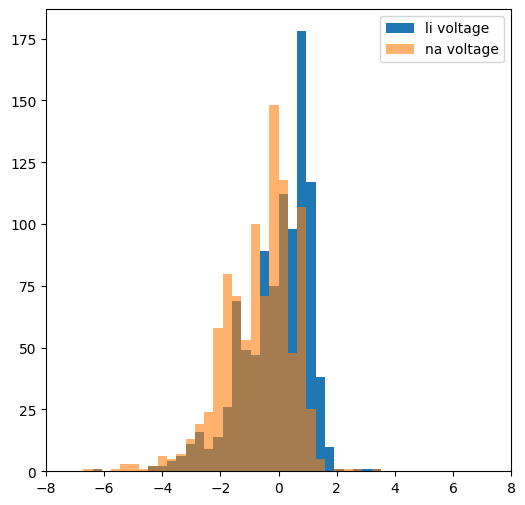

In [4]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage'],label="li voltage",bins=50,range=(-8,8))
plt.hist(df['Na_voltage'],label="na voltage",bins=50,range=(-8,8),alpha=0.6)
plt.xlim(-8,8)
plt.legend()
plt.show()

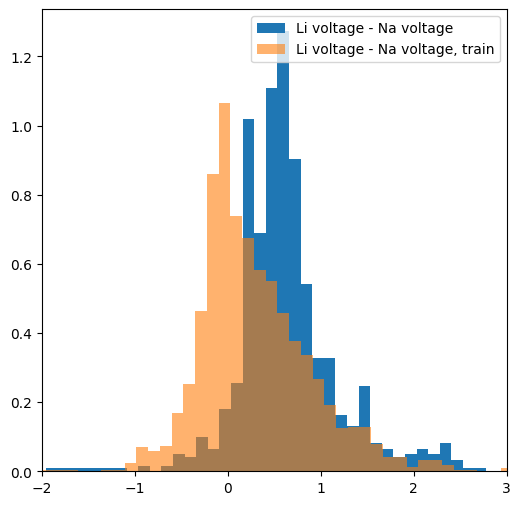

In [5]:
plt.figure(figsize=(6,6))
plt.hist(df['Li_voltage']-df['Na_voltage'],label="Li voltage - Na voltage",bins=50,density=True)
plt.hist(df_train['Li_voltage']-df_train['Na_voltage'],label="Li voltage - Na voltage, train",bins=50,alpha=0.6,density=True)
plt.xlim(-2,3)
plt.legend()
plt.show()

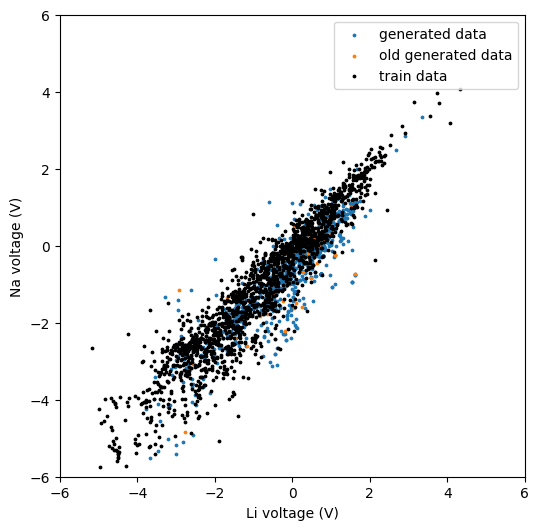

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(df['Li_voltage'],df['Na_voltage'],s=3,label="generated data")
plt.scatter(df_old['Li_voltage'],df_old['Na_voltage'],s=3,label="old generated data")
plt.scatter(df_train['Li_voltage'],df_train['Na_voltage'],s=3,label="train data",c='k')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.xlabel("Li voltage (V)")
plt.ylabel("Na voltage (V)")
plt.legend()
plt.show()


In [10]:
df_to_add = df[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']

/tmp/ipykernel_3329358/4151272627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_add['Na_voltage'] = df_to_add['Li_voltage'] - df_to_add['Na_voltage']


In [11]:
df_old_to_add = df_old[['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'Li_structure']]
df_old_to_add.columns = ['pretty_formula', 'num_atoms', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom', 'Li_voltage', 'Na_voltage', 'cif']
df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage'] 

/tmp/ipykernel_3329358/1798932268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_old_to_add['Na_voltage'] = df_old_to_add['Li_voltage'] - df_old_to_add['Na_voltage']


In [12]:
df_merged = pd.concat([df_train_diff,df_to_add,df_old_to_add],ignore_index=True)

In [13]:
# remove nan rows except if Nan is only in 'material_id' column
df_merged_cleaned = df_merged.dropna(subset=['Li_voltage', 'Na_voltage', 'host_energy_per_atom', 'Li_energy_per_atom', 'Na_energy_per_atom'])

In [14]:
df_merged_cleaned.to_csv("train_extended_cleaned.csv",index=False)

In [15]:
df_merged_cleaned

,pretty_formula,material_id,num_atoms,host_energy_per_atom,Li_energy_per_atom,Na_energy_per_atom,Li_voltage,Na_voltage,cif
0,Rb2LiBi2O5,mp-975106,10.0,-5.001463,-4.840352,-4.775824,-1.552852,-0.278626,# generated using pymatgen\ndata_Rb2LiBi2O5\n_...
1,LiVCl2O,mp-1216404,5.0,-5.365562,-5.168905,-4.801249,-0.560927,0.914376,# generated using pymatgen\ndata_LiVCl2O\n_sym...
2,LiScTl(MoO4)2,mp-19450,13.0,-7.246476,-6.905751,-6.844393,-2.126157,-0.126252,# generated using pymatgen\ndata_LiScTl(MoO4)2...
3,Li4Cr3FeO8,mp-756058,16.0,-6.821576,-6.671563,-6.509723,0.678274,0.370821,# generated using pymatgen\ndata_Li4Cr3FeO8\n_...
4,Ba4Li(Co2O5)2,mp-1076439,19.0,-6.059365,-5.934136,-5.872205,-1.263181,0.252789,# generated using pymatgen\ndata_Ba4Li(Co2O5)2...
...,...,...,...,...,...,...,...,...,...
3862,LiCr2NiO6,NaN,10.0,-6.418833,-6.344823,-6.205362,0.735528,0.470709,# generated using pymatgen\ndata_LiCr2NiO6\n_s...
3864,LiAlCr5O8,NaN,15.0,-7.741191,-7.435713,-7.356704,-1.784173,0.261232,# generated using pymatgen\ndata_LiAlCr5O8\n_s...
3866,LiCr2(NiO2)2,NaN,9.0,-6.042746,-5.595628,-5.691299,-2.924517,-1.784939,# generated using pymatgen\ndata_LiCr2(NiO2)2\...
3868,LiCr(SbO4)2,NaN,12.0,-6.106551,-6.136741,-6.015783,1.525626,0.527599,# generated using pymatgen\ndata_LiCr(SbO4)2\n...
